# Ring optimization trajectory for one molecule (nglview variant)

This notebook reproduces the ring optimization logic used by `scripts/reconstruct_single.py`, stores every optimization iterate as a frame, and visualizes selected conformer trajectories with `nglview`.


In [1]:
import json
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nglview as nv
import mdtraj as md
from rdkit import Chem
from scipy.optimize import NonlinearConstraint, minimize

from ringer.utils import internal_coords


In [2]:
ROOT = Path.cwd()
if not (ROOT / "ringer").exists():
    ROOT = ROOT.parent

MOL_NAME = "F.Mec.q.Y.pickle"
PRE_OPT_PATH = ROOT / "sample/reconstructed_mols_no_opt" / MOL_NAME
OPT_PATH = ROOT / "sample/reconstructed_mols" / MOL_NAME
SAMPLES_PATH = ROOT / "sample/samples.pickle"
MEAN_DIST_PATH = ROOT / "assets/models/conditional/training_mean_distances.json"

MAX_CONF: Optional[int] = 1
MAXITER = 100
USE_ANGLES_AS_CONSTRAINTS = False
MOL_BLOCK_STYLE = {"stick": {"radius": 0.12}, "sphere": {"radius": 0.18}}

assert PRE_OPT_PATH.exists(), PRE_OPT_PATH
assert OPT_PATH.exists(), OPT_PATH
assert SAMPLES_PATH.exists(), SAMPLES_PATH
assert MEAN_DIST_PATH.exists(), MEAN_DIST_PATH
print(ROOT)

/mnt/HDD1/Codes/ringer


In [3]:
def _load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def _load_structure_by_name(samples_path: Path, mol_name: str) -> Dict:
    structures = _load_pickle(samples_path)
    for key, structure in structures.items():
        if Path(key).name == mol_name:
            return structure
    raise KeyError(f"No structure found for {mol_name}")


def _kabsch_rmsd(ref_xyz: np.ndarray, probe_xyz: np.ndarray) -> float:
    ref = np.asarray(ref_xyz, dtype=float)
    probe = np.asarray(probe_xyz, dtype=float)
    ref_centered = ref - ref.mean(axis=0)
    probe_centered = probe - probe.mean(axis=0)

    cov = probe_centered.T @ ref_centered
    u, _, vt = np.linalg.svd(cov)
    sign = np.sign(np.linalg.det(u @ vt))
    rot = u @ np.diag([1.0, 1.0, sign]) @ vt
    probe_aligned = probe_centered @ rot
    return float(np.sqrt(np.mean(np.sum((probe_aligned - ref_centered) ** 2, axis=1))))


def _mol_with_replaced_ring(mol_template: Chem.Mol, ring_idxs: List[int], ring_xyz: np.ndarray) -> Chem.Mol:
    conf = Chem.Conformer(mol_template.GetConformer(0))
    for atom_idx, pos in zip(ring_idxs, np.asarray(ring_xyz, dtype=float)):
        conf.SetAtomPosition(int(atom_idx), [float(pos[0]), float(pos[1]), float(pos[2])])
    new_mol = Chem.Mol(mol_template, quickCopy=True)
    new_mol.RemoveAllConformers()
    new_mol.AddConformer(conf, assignId=True)
    return new_mol


@dataclass
class ConformerTrajectory:
    conf_idx: int
    success: bool
    status: int
    message: str
    niter: int
    objective: List[float]
    ring_xyz_frames: List[np.ndarray]
    rmsd_to_pre: List[float]
    rmsd_to_opt: List[float]


def optimize_with_trajectory(
    pre_mol: Chem.Mol,
    opt_mol: Chem.Mol,
    structure: Dict,
    mean_bond_dists: Dict[str, float],
    conf_idx: int,
    maxiter: int = 100,
    angles_as_constraints: bool = False,
) -> ConformerTrajectory:
    ring_idxs = list(structure["dihedral"].columns)
    ring_internal = internal_coords.RingInternalCoordinates(ring_idxs)

    bond_dists = pd.Series(
        data=(mean_bond_dists[label] for label in structure["atom_labels"]),
        index=ring_idxs,
        dtype=float,
    )
    angle_target = structure["angle"].loc[conf_idx]
    dihedral_target = structure["dihedral"].loc[conf_idx]

    xyz0 = pre_mol.GetConformer(conf_idx).GetPositions()[ring_idxs]
    trans_mat = internal_coords.compute_canonical_transform(xyz0)
    inv_trans = np.linalg.inv(trans_mat)
    x0 = internal_coords.apply_affine_transform(xyz0, trans_mat).ravel()

    objective: List[float] = []
    x_frames: List[np.ndarray] = [x0.copy()]

    if angles_as_constraints:
        raise NotImplementedError("Set up angle constraints if needed for your run settings.")

    def objective_with_grad(x: np.ndarray):
        loss, grad = internal_coords.angle_and_dihedral_loss(
            x,
            internal_coords=ring_internal,
            angle_vals_target=np.asarray(angle_target),
            dihedral_vals_target=np.asarray(dihedral_target),
            grad=True,
        )
        objective.append(float(loss))
        return loss, grad

    dist_constraint = NonlinearConstraint(
        ring_internal.compute_distances,
        lb=np.asarray(bond_dists),
        ub=np.asarray(bond_dists),
        jac=ring_internal.compute_distance_jacobian,
    )

    def callback(xk: np.ndarray, *args):
        x_frames.append(np.asarray(xk).copy())

    result = minimize(
        objective_with_grad,
        x0,
        constraints=[dist_constraint],
        jac=True,
        options={"maxiter": int(maxiter)},
        callback=callback,
    )

    if not np.allclose(x_frames[-1], result.x):
        x_frames.append(np.asarray(result.x).copy())

    ring_xyz_frames = [
        internal_coords.apply_affine_transform(x.reshape(-1, 3), inv_trans) for x in x_frames
    ]

    pre_ring = pre_mol.GetConformer(conf_idx).GetPositions()[ring_idxs]
    opt_ring = opt_mol.GetConformer(conf_idx).GetPositions()[ring_idxs]
    rmsd_to_pre = [_kabsch_rmsd(pre_ring, frame) for frame in ring_xyz_frames]
    rmsd_to_opt = [_kabsch_rmsd(opt_ring, frame) for frame in ring_xyz_frames]

    return ConformerTrajectory(
        conf_idx=int(conf_idx),
        success=bool(result.success),
        status=int(result.status),
        message=str(result.message),
        niter=int(getattr(result, "nit", len(x_frames) - 1)),
        objective=objective,
        ring_xyz_frames=ring_xyz_frames,
        rmsd_to_pre=rmsd_to_pre,
        rmsd_to_opt=rmsd_to_opt,
    )

In [4]:
pre_mol = _load_pickle(PRE_OPT_PATH)
opt_mol = _load_pickle(OPT_PATH)
structure = _load_structure_by_name(SAMPLES_PATH, MOL_NAME)

with MEAN_DIST_PATH.open("r") as f:
    mean_bond_dists = json.load(f)

n_conf_total = pre_mol.GetNumConformers()
if MAX_CONF is None:
    conf_indices = list(range(n_conf_total))
else:
    conf_indices = list(range(min(MAX_CONF, n_conf_total)))

print(f"Loaded {MOL_NAME}: {n_conf_total} conformers; running {len(conf_indices)} conformers")

Loaded F.Mec.q.Y.pickle: 2756 conformers; running 1 conformers


In [5]:
trajectories: Dict[int, ConformerTrajectory] = {}
for conf_idx in conf_indices:
    trajectories[conf_idx] = optimize_with_trajectory(
        pre_mol=pre_mol,
        opt_mol=opt_mol,
        structure=structure,
        mean_bond_dists=mean_bond_dists,
        conf_idx=conf_idx,
        maxiter=MAXITER,
        angles_as_constraints=USE_ANGLES_AS_CONSTRAINTS,
    )

print(
    f"Completed: {sum(t.success for t in trajectories.values())}/{len(trajectories)} successful optimization runs"
)

Completed: 1/1 successful optimization runs


In [6]:
summary_rows = []
for conf_idx, traj in trajectories.items():
    summary_rows.append(
        {
            "conf_idx": conf_idx,
            "success": traj.success,
            "niter": traj.niter,
            "nframes": len(traj.ring_xyz_frames),
            "rmsd_pre_start": traj.rmsd_to_pre[0],
            "rmsd_pre_end": traj.rmsd_to_pre[-1],
            "rmsd_opt_start": traj.rmsd_to_opt[0],
            "rmsd_opt_end": traj.rmsd_to_opt[-1],
            "objective_end": traj.objective[-1] if traj.objective else np.nan,
            "message": traj.message,
        }
    )
summary_df = pd.DataFrame(summary_rows).sort_values("conf_idx").reset_index(drop=True)
summary_df.head(10)

,conf_idx,success,niter,nframes,rmsd_pre_start,rmsd_pre_end,rmsd_opt_start,rmsd_opt_end,objective_end,message
0,0,True,19,20,1.636401e-15,0.234559,1.2855,1.23361,0.255534,Optimization terminated successfully


In [7]:
summary_df[["niter", "nframes", "rmsd_pre_end", "rmsd_opt_end"]].describe()

,niter,nframes,rmsd_pre_end,rmsd_opt_end
count,1.0,1.0,1.000000,1.00000
mean,19.0,20.0,0.234559,1.23361
std,NaN,NaN,NaN,NaN
min,19.0,20.0,0.234559,1.23361
25%,19.0,20.0,0.234559,1.23361
50%,19.0,20.0,0.234559,1.23361
75%,19.0,20.0,0.234559,1.23361
max,19.0,20.0,0.234559,1.23361


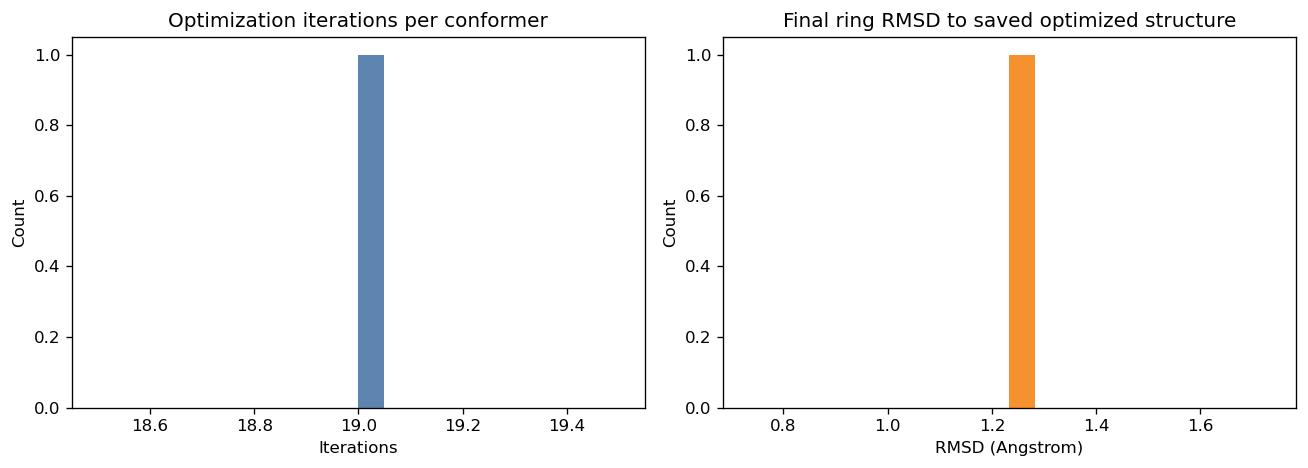

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

axes[0].hist(summary_df["niter"], bins=20, color="#4C78A8", alpha=0.9)
axes[0].set_title("Optimization iterations per conformer")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Count")

axes[1].hist(summary_df["rmsd_opt_end"], bins=20, color="#F58518", alpha=0.9)
axes[1].set_title("Final ring RMSD to saved optimized structure")
axes[1].set_xlabel("RMSD (Angstrom)")
axes[1].set_ylabel("Count")

plt.tight_layout()

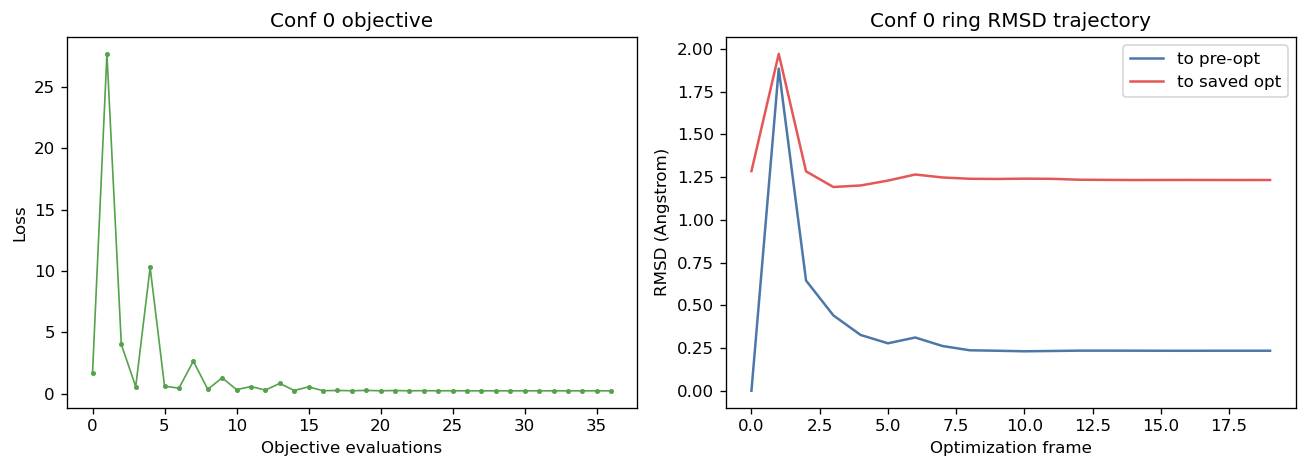

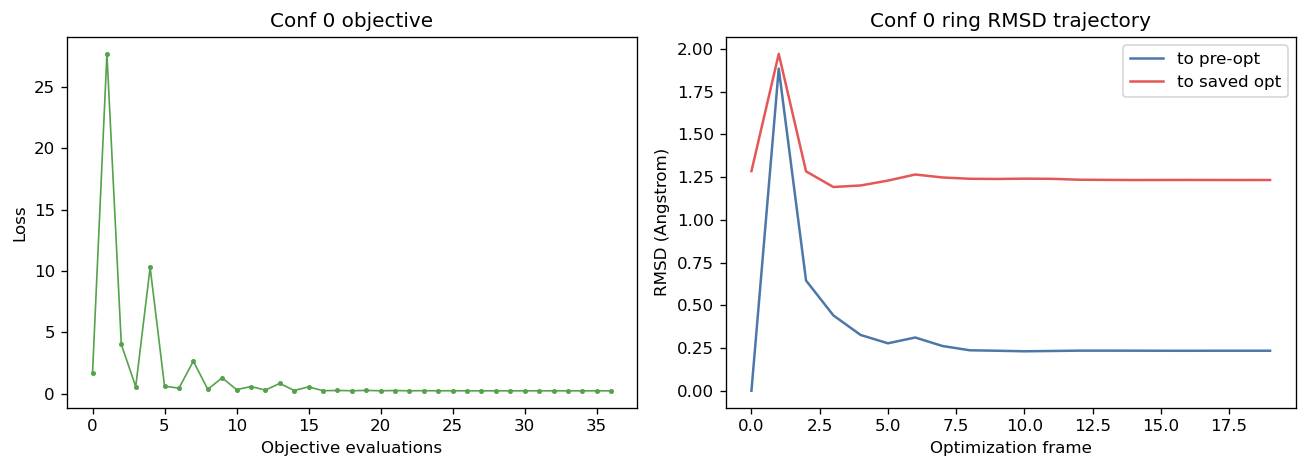

In [9]:
def plot_conformer_diagnostics(conf_idx: int):
    traj = trajectories[int(conf_idx)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

    axes[0].plot(traj.objective, marker="o", markersize=2, linewidth=1, color="#54A24B")
    axes[0].set_title(f"Conf {conf_idx} objective")
    axes[0].set_xlabel("Objective evaluations")
    axes[0].set_ylabel("Loss")

    axes[1].plot(traj.rmsd_to_pre, label="to pre-opt", color="#4C78A8")
    axes[1].plot(traj.rmsd_to_opt, label="to saved opt", color="#E45756")
    axes[1].set_title(f"Conf {conf_idx} ring RMSD trajectory")
    axes[1].set_xlabel("Optimization frame")
    axes[1].set_ylabel("RMSD (Angstrom)")
    axes[1].legend()

    plt.tight_layout()
    return fig


plot_conformer_diagnostics(conf_idx=0)

In [10]:
def _write_conformer_trajectory_pdb(conf_idx: int, out_path: Path, stride: int = 1) -> Path:
    conf_idx = int(conf_idx)
    traj = trajectories[conf_idx]
    ring_idxs = list(structure["dihedral"].columns)

    base_mol = Chem.Mol(pre_mol, quickCopy=True)
    base_mol.RemoveAllConformers()
    base_mol.AddConformer(Chem.Conformer(pre_mol.GetConformer(conf_idx)), assignId=True)

    with out_path.open("w", encoding="ascii") as f:
        for model_idx, ring_xyz in enumerate(traj.ring_xyz_frames):
            if model_idx % max(1, int(stride)) != 0 and model_idx != len(traj.ring_xyz_frames) - 1:
                continue
            model = _mol_with_replaced_ring(base_mol, ring_idxs, ring_xyz)
            pdb_block = Chem.MolToPDBBlock(model, confId=0)
            f.write(f"MODEL     {model_idx + 1}\n")
            for line in pdb_block.splitlines():
                if line.startswith(("ATOM", "HETATM", "CONECT", "TER")):
                    f.write(line + "\n")
            f.write("ENDMDL\n")
        f.write("END\n")

    return out_path


def show_ring_trajectory_nglview(
    conf_idx: int,
    stride: int = 1,
    width: str = "900px",
    height: str = "620px",
):
    conf_idx = int(conf_idx)
    ngl_dir = ROOT / "sample/analysis/optimization_trajectory/nglview"
    ngl_dir.mkdir(parents=True, exist_ok=True)
    pdb_path = ngl_dir / f"{Path(MOL_NAME).stem}_conf{conf_idx}_trajectory.pdb"
    _write_conformer_trajectory_pdb(conf_idx=conf_idx, out_path=pdb_path, stride=stride)

    md_traj = md.load(str(pdb_path))
    view = nv.show_mdtraj(md_traj)
    view.clear_representations()
    view.add_ball_and_stick(aspectRatio=2.2, colorScheme="element")
    view.center()
    view.layout.width = width
    view.layout.height = height
    return view


show_ring_trajectory_nglview(conf_idx=0, stride=1)


NGLWidget(layout=Layout(height='620px', width='900px'), max_frame=19)

In [11]:
OUT_DIR = ROOT / "sample/analysis/optimization_trajectory"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_out = OUT_DIR / f"{Path(MOL_NAME).stem}_trajectory_summary.csv"
summary_df.to_csv(summary_out, index=False)

ring_frames_by_conf = {
    conf_idx: np.stack(traj.ring_xyz_frames, axis=0)
    for conf_idx, traj in trajectories.items()
}
ring_frames_out = OUT_DIR / f"{Path(MOL_NAME).stem}_ring_frames.npz"
np.savez_compressed(ring_frames_out, **{str(k): v for k, v in ring_frames_by_conf.items()})

ring_idxs = list(structure["dihedral"].columns)
full_frames_by_conf = {}
for conf_idx, traj in trajectories.items():
    base_xyz = pre_mol.GetConformer(conf_idx).GetPositions()
    full_frames = []
    for ring_xyz in traj.ring_xyz_frames:
        xyz = np.array(base_xyz, copy=True)
        xyz[ring_idxs] = ring_xyz
        full_frames.append(xyz)
    full_frames_by_conf[conf_idx] = np.stack(full_frames, axis=0)

full_frames_out = OUT_DIR / f"{Path(MOL_NAME).stem}_full_atom_frames.npz"
np.savez_compressed(full_frames_out, **{str(k): v for k, v in full_frames_by_conf.items()})

print(summary_out)
print(ring_frames_out)
print(full_frames_out)

/mnt/HDD1/Codes/ringer/sample/analysis/optimization_trajectory/F.Mec.q.Y_trajectory_summary.csv
/mnt/HDD1/Codes/ringer/sample/analysis/optimization_trajectory/F.Mec.q.Y_ring_frames.npz
/mnt/HDD1/Codes/ringer/sample/analysis/optimization_trajectory/F.Mec.q.Y_full_atom_frames.npz


In [12]:
def export_conformer_trajectory_sdf(conf_idx: int, out_path: Path) -> Path:
    conf_idx = int(conf_idx)
    ring_idxs = list(structure["dihedral"].columns)
    traj = trajectories[conf_idx]

    base_mol = Chem.Mol(pre_mol, quickCopy=True)
    base_mol.RemoveAllConformers()
    base_mol.AddConformer(Chem.Conformer(pre_mol.GetConformer(conf_idx)), assignId=True)

    writer = Chem.SDWriter(str(out_path))
    for step_idx, ring_xyz in enumerate(traj.ring_xyz_frames):
        mol_step = _mol_with_replaced_ring(base_mol, ring_idxs, ring_xyz)
        mol_step.SetProp("conf_idx", str(conf_idx))
        mol_step.SetProp("opt_step", str(step_idx))
        mol_step.SetProp("n_frames", str(len(traj.ring_xyz_frames)))
        writer.write(mol_step)
    writer.close()
    return out_path


example_sdf = OUT_DIR / f"{Path(MOL_NAME).stem}_conf0_trajectory.sdf"
export_conformer_trajectory_sdf(conf_idx=0, out_path=example_sdf)
print(example_sdf)


/mnt/HDD1/Codes/ringer/sample/analysis/optimization_trajectory/F.Mec.q.Y_conf0_trajectory.sdf
